# BoolDog basic tutorial <a class="jp-toc-ignore"></a> 

Basic demonstration of BoolDog functionality. 

In [1]:
from booldog import BoolDogModel

INFO 2026-03-04 19:00:26,737 booldog:<module> BoolDog version: 0.1.0


# Toy example

In [2]:
bnet = '''
ETR_CTR, (ETR & CTR) & !ET
EIN2, !ETR_CTR & EIN2
'''
node_names = {
    "CTR": "CTR protein",
    "EIN2": "EIN2 protein",
    "ET": "ET metabolite",
    "ETR": "ETR protein",
    "ETR_CTR": "ETR|CTR complex"
}


bn = BoolDogModel.from_bnet(bnet, node_names=node_names)

INFO 2026-03-04 19:00:26,743 booldog.network:__init__ Node 'CTR' has no rule. Assuming 'input' node.
INFO 2026-03-04 19:00:26,744 booldog.network:__init__ Node 'ET' has no rule. Assuming 'input' node.
INFO 2026-03-04 19:00:26,744 booldog.network:__init__ Node 'ETR' has no rule. Assuming 'input' node.
INFO 2026-03-04 19:00:26,749 booldog.network:__init__ Created Network with 5 nodes.


In [3]:
bn.nodes

{'ETR_CTR': BoolDogNode(name='ETR|CTR complex', rule='(ETR & CTR) & !ET'),
 'EIN2': BoolDogNode(name='EIN2 protein', rule='!ETR_CTR & EIN2'),
 'CTR': BoolDogNode(name='CTR protein', rule='CTR'),
 'ET': BoolDogNode(name='ET metabolite', rule='ET'),
 'ETR': BoolDogNode(name='ETR protein', rule='ETR')}

In [4]:
bn.get_rule("ETR_CTR")

'(ETR & CTR) & !ET'

In [5]:
g = bn.to_networkx(as_logic_circuit=True)

In [6]:
print(bn.to_bnet())

targets, factors
ETR_CTR, (ETR & CTR) & !ET
EIN2, !ETR_CTR & EIN2
CTR, CTR
ET, ET
ETR, ETR



# Boolean simulation

## State transition graph

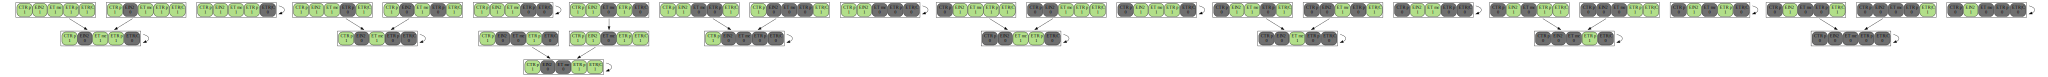

In [7]:
stg = bn.boolean_simulation()
stg.plot_stg()

## Stable states

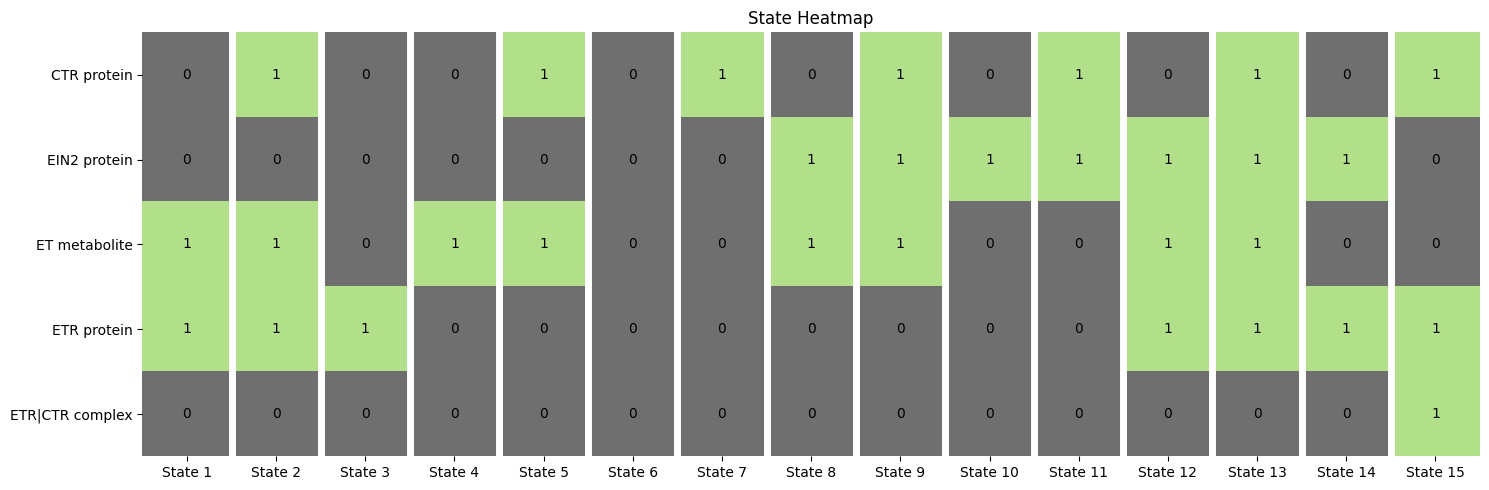

In [8]:
steady_states = bn.steady_states()
steady_states.plot_state_space()

# Continous simulation

In [9]:
bn.steady_states().state_space

[{'CTR': 0, 'EIN2': 0, 'ET': 1, 'ETR': 1, 'ETR_CTR': 0},
 {'CTR': 1, 'EIN2': 0, 'ET': 1, 'ETR': 1, 'ETR_CTR': 0},
 {'CTR': 0, 'EIN2': 0, 'ET': 0, 'ETR': 1, 'ETR_CTR': 0},
 {'CTR': 0, 'EIN2': 0, 'ET': 1, 'ETR': 0, 'ETR_CTR': 0},
 {'CTR': 1, 'EIN2': 0, 'ET': 1, 'ETR': 0, 'ETR_CTR': 0},
 {'CTR': 0, 'EIN2': 0, 'ET': 0, 'ETR': 0, 'ETR_CTR': 0},
 {'CTR': 1, 'EIN2': 0, 'ET': 0, 'ETR': 0, 'ETR_CTR': 0},
 {'CTR': 0, 'EIN2': 1, 'ET': 1, 'ETR': 0, 'ETR_CTR': 0},
 {'CTR': 1, 'EIN2': 1, 'ET': 1, 'ETR': 0, 'ETR_CTR': 0},
 {'CTR': 0, 'EIN2': 1, 'ET': 0, 'ETR': 0, 'ETR_CTR': 0},
 {'CTR': 1, 'EIN2': 1, 'ET': 0, 'ETR': 0, 'ETR_CTR': 0},
 {'CTR': 0, 'EIN2': 1, 'ET': 1, 'ETR': 1, 'ETR_CTR': 0},
 {'CTR': 1, 'EIN2': 1, 'ET': 1, 'ETR': 1, 'ETR_CTR': 0},
 {'CTR': 0, 'EIN2': 1, 'ET': 0, 'ETR': 1, 'ETR_CTR': 0},
 {'CTR': 1, 'EIN2': 0, 'ET': 0, 'ETR': 1, 'ETR_CTR': 1}]

INFO 2026-03-04 19:00:27,436 booldog.continuous.semi_quantitative:continuous_simulation Status: Generating ODE system ... 
INFO 2026-03-04 19:00:27,437 booldog.continuous.ode_factory:__init__ Creating ODE system for normalisedhillcube.
INFO 2026-03-04 19:00:27,439 booldog.continuous.semi_quantitative:continuous_simulation Status: ... done.
INFO 2026-03-04 19:00:27,440 booldog.continuous.semi_quantitative:continuous_simulation Status: Start
INFO 2026-03-04 19:00:27,991 booldog.continuous.semi_quantitative:continuous_simulation Status: End


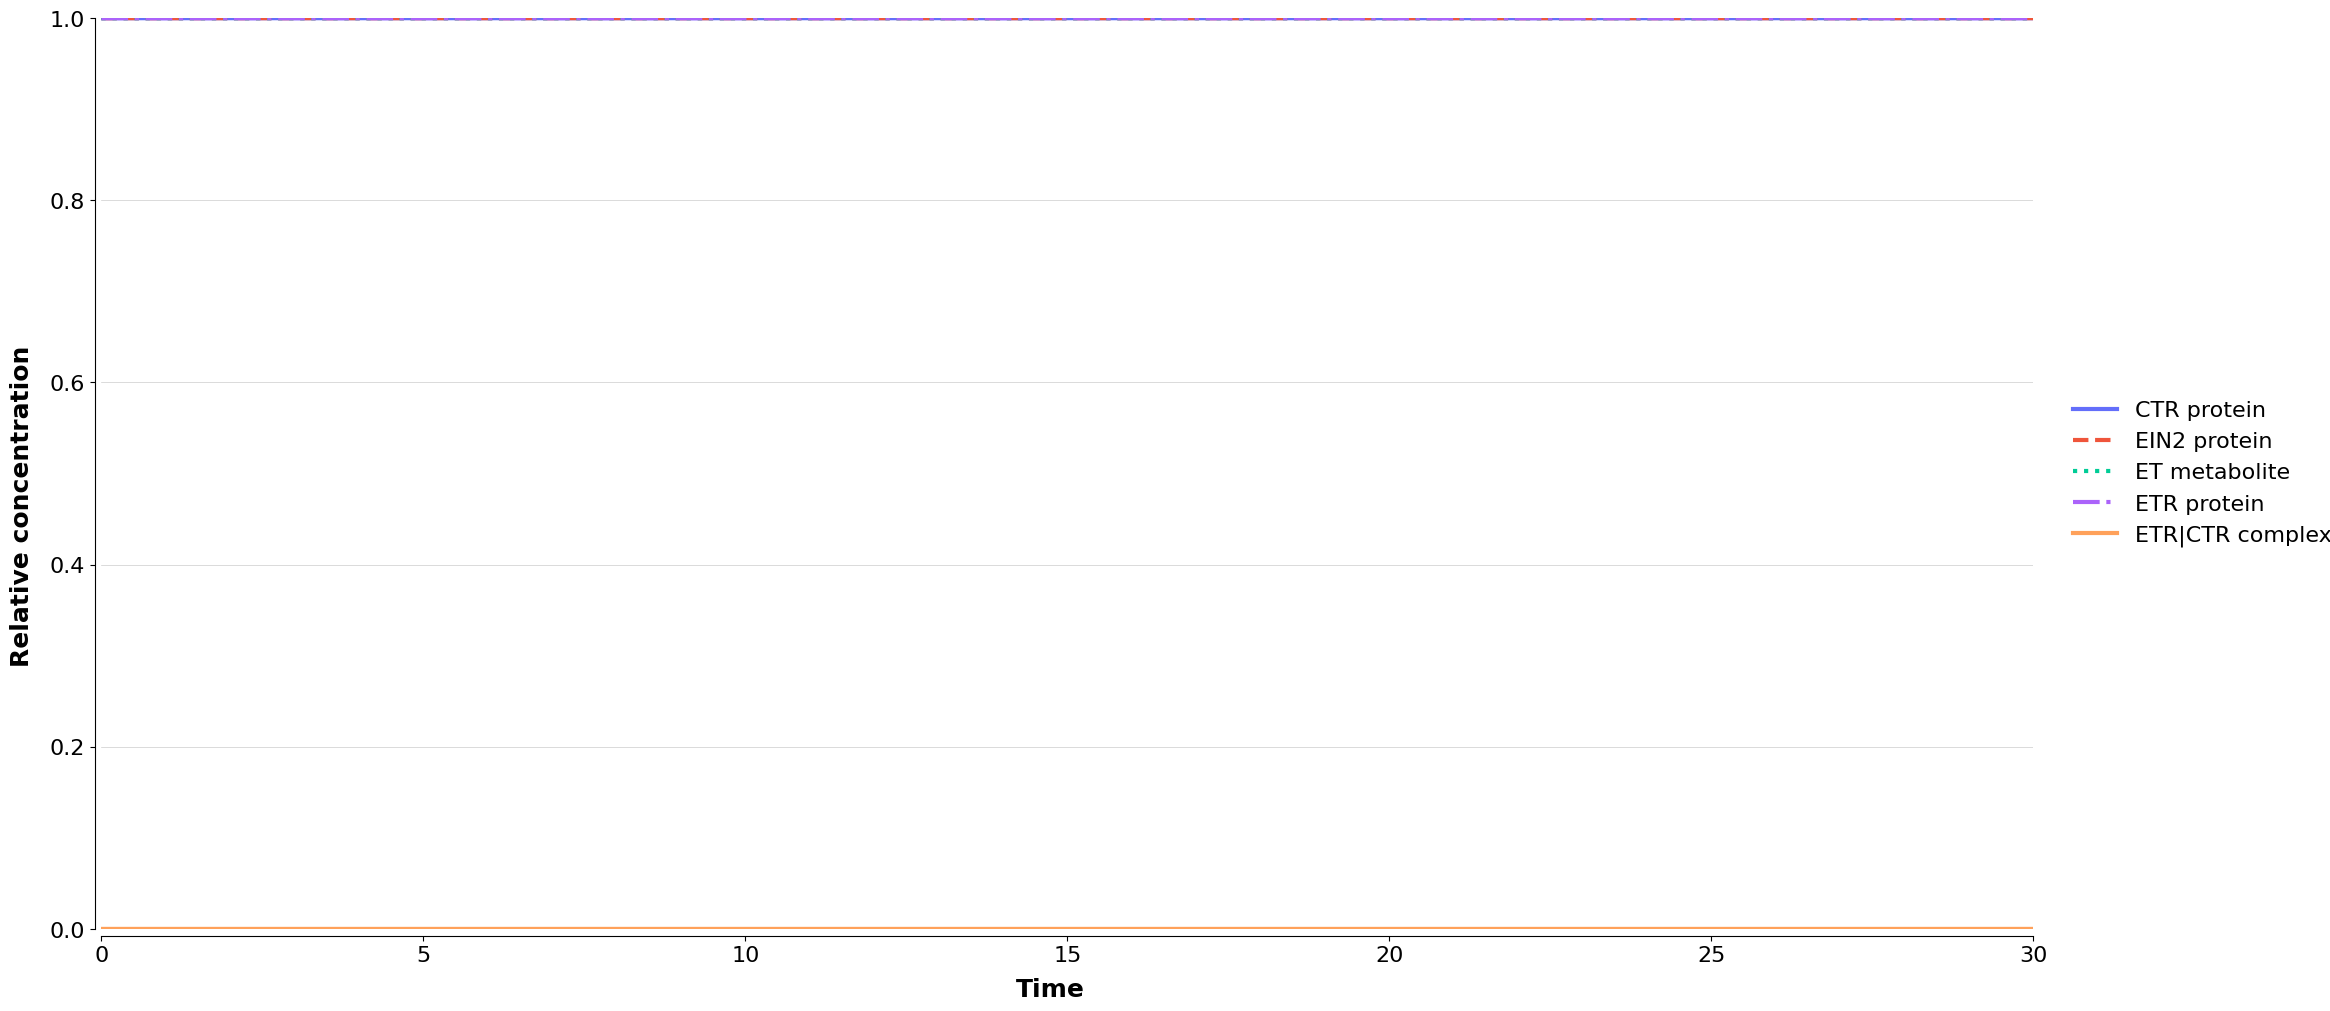

(<Figure size 2000x1000 with 1 Axes>, array([[<Axes: >]], dtype=object))

In [10]:
# Choose a steady stare to start from
simulation = bn.continuous_simulation(
    transform="normalisedhillcube",
    initial_state={'CTR': 1, 'EIN2': 1, 'ET': 1, 'ETR': 1, 'ETR_CTR': 0},
)
simulation.plot()

## Continous simulation with an event

INFO 2026-03-04 19:00:28,318 booldog.continuous.semi_quantitative:continuous_simulation Status: Generating ODE system ... 
INFO 2026-03-04 19:00:28,319 booldog.continuous.ode_factory:__init__ Creating ODE system for normalisedhillcube.
INFO 2026-03-04 19:00:28,320 booldog.continuous.semi_quantitative:continuous_simulation Status: ... done.
INFO 2026-03-04 19:00:28,321 booldog.continuous.semi_quantitative:continuous_simulation Status: Start
INFO 2026-03-04 19:00:28,427 booldog.continuous.semi_quantitative:continuous_simulation Status: Event at 4.0:
        ET -> 0.00 (duration  0)

INFO 2026-03-04 19:00:28,877 booldog.continuous.semi_quantitative:continuous_simulation Status: End


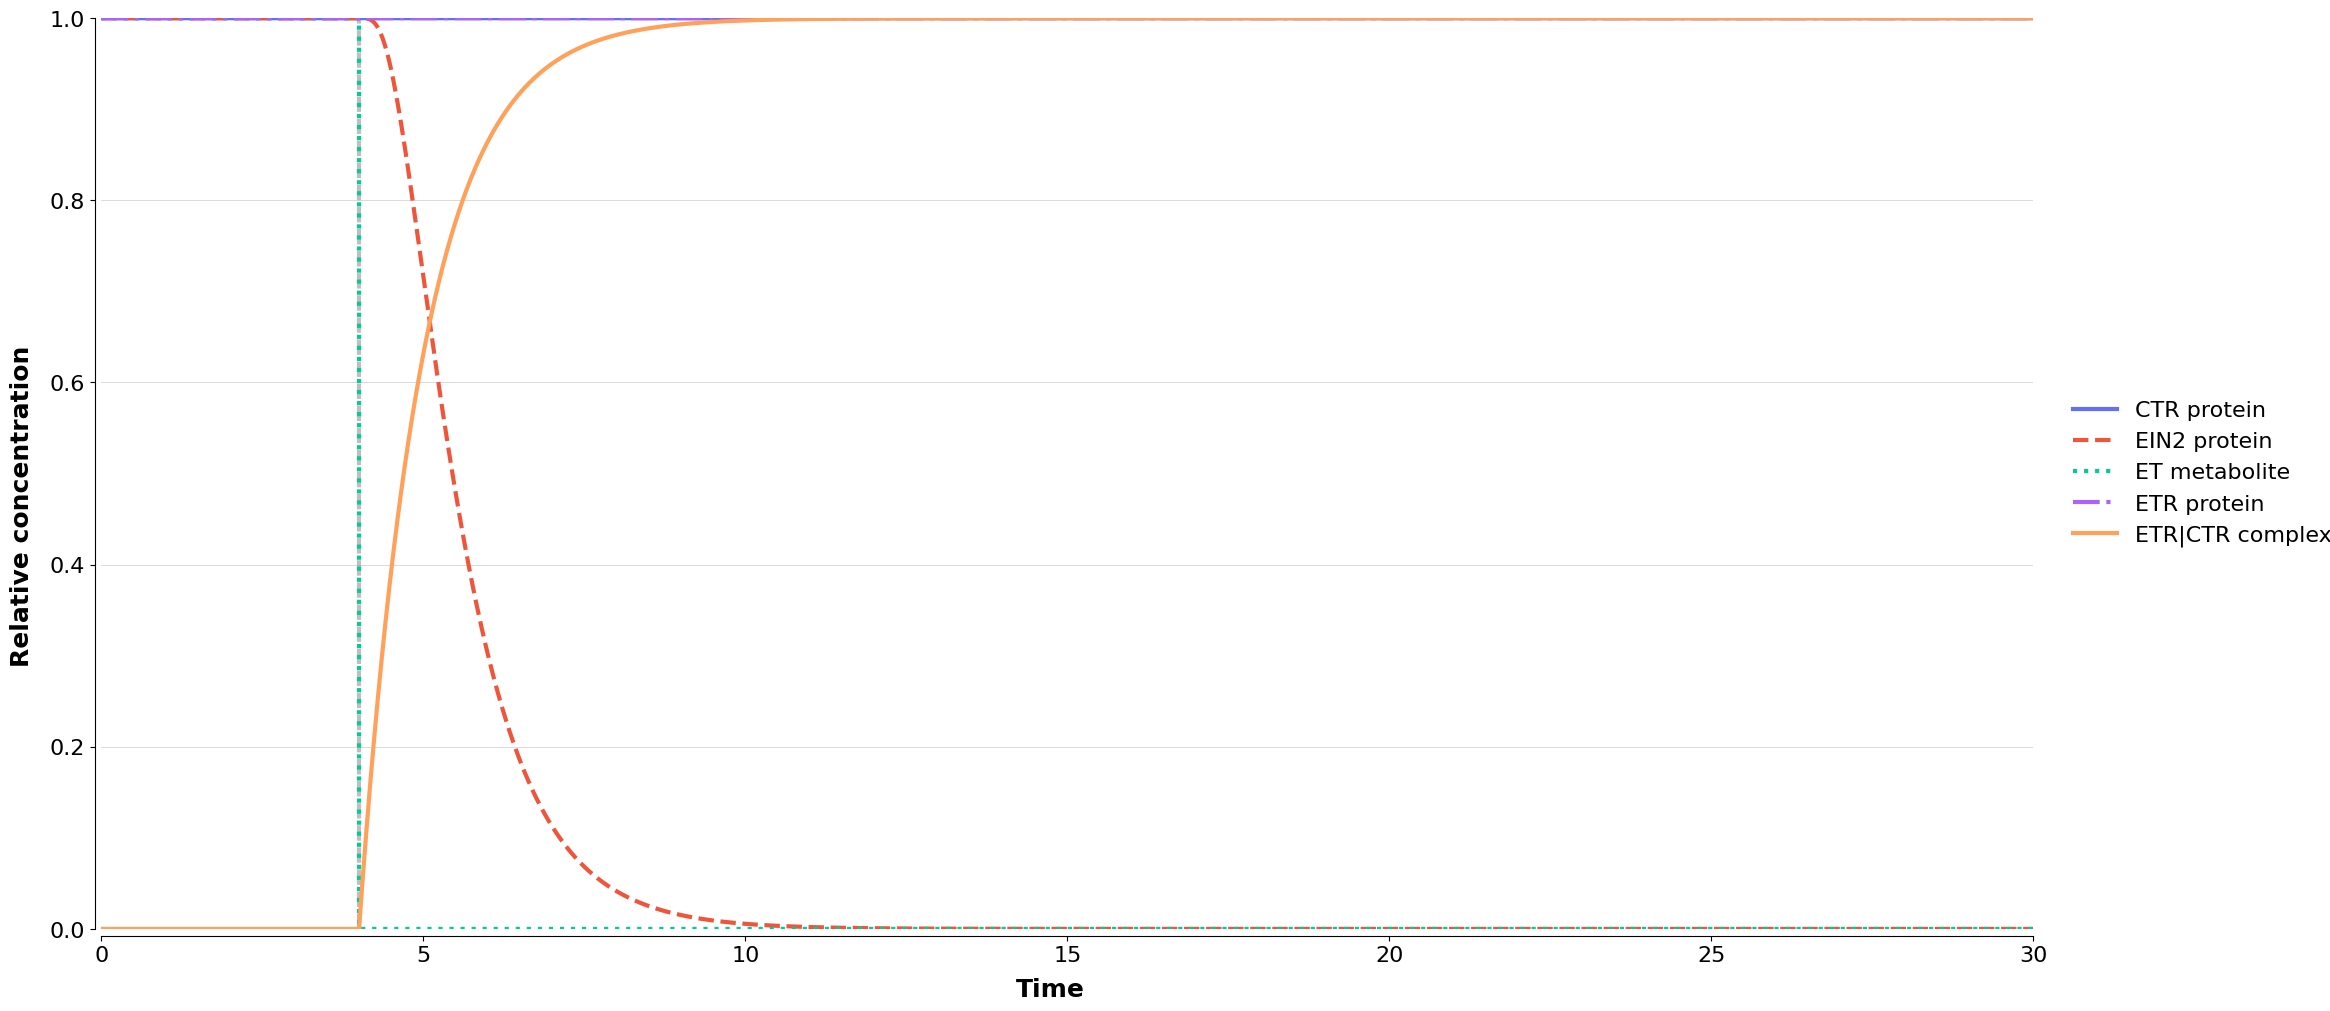

(<Figure size 2000x1000 with 1 Axes>, array([[<Axes: >]], dtype=object))

In [11]:
# Add an event!
simulation = bn.continuous_simulation(
    transform="normalisedhillcube",
    initial_state={'CTR': 1, 'EIN2': 1, 'ET': 1, 'ETR': 1, 'ETR_CTR': 0},
    node_events={'time':4, 'node':'ET', 'value':0},
)
simulation.plot()

## Save simulation results

In [12]:
simulation.export("files/basic_simulation_event.tsv")

WARNING 2026-03-04 19:00:29,169 booldog.utils.misc:file_writable files/basic_simulation_event.tsv already exists and will be overwritten!
INFO 2026-03-04 19:00:29,191 booldog.simulation_result.continuous_result:export Saved simulation results to files/basic_simulation_event.tsv.
